<a href="https://colab.research.google.com/github/Ash-ioL/tf-cnn-mnist/blob/main/cnn_mnist_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers

data = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = data.load_data()

x_train, x_test = x_train/255, x_test/255
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

layer1 = layers.Conv2D(64, (3, 3), input_shape=(28, 28, 1))
layer2 = layers.MaxPooling2D((2, 2))
layer3 = layers.Conv2D(64, (3, 3))
layer4 = layers.MaxPooling2D((2, 2))
layer5 = layers.Flatten()
layer6 = layers.Dense(64, activation="relu")
layer7 = layers.Dense(10, activation="softmax")

model = models.Sequential()
model.add(layer1)
model.add(layer2)
model.add(layer3)
model.add(layer4)
model.add(layer5)
model.add(layer6)
model.add(layer7)

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)

model.evaluate(x_test, y_test, verbose=2)

model.save("mnist_cnn.keras")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 88s 46ms/step - accuracy: 0.9574 - loss: 0.1416 - val_accuracy: 0.9822 - val_loss: 0.0560
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 45ms/step - accuracy: 0.9849 - loss: 0.0484 - val_accuracy: 0.9842 - val_loss: 0.0520
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.9886 - loss: 0.0350 - val_accuracy: 0.9819 - val_loss: 0.0638
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 45ms/step - accuracy: 0.9913 - loss: 0.0271 - val_accuracy: 0.9861 - val_loss: 0.0462
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.9933 - loss: 0.0203 - val_accuracy: 0.9857 - val_loss: 0.0514
313/313 - 3s - 11ms/step - accuracy: 0.9857 - loss: 0.0514


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
incorrect: 143
total: 10000
accuracy: 98.57


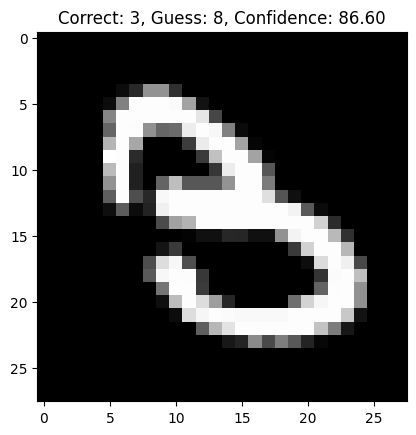

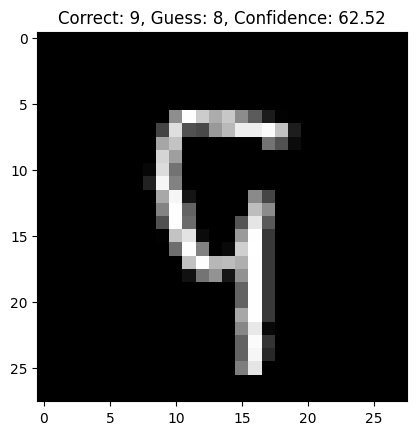

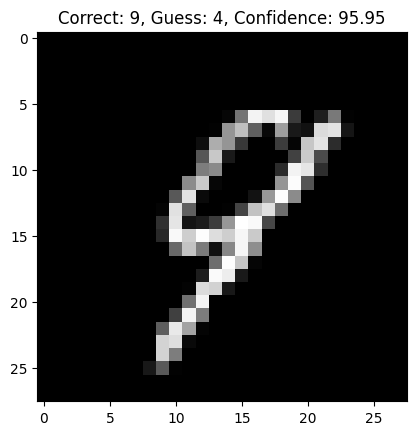

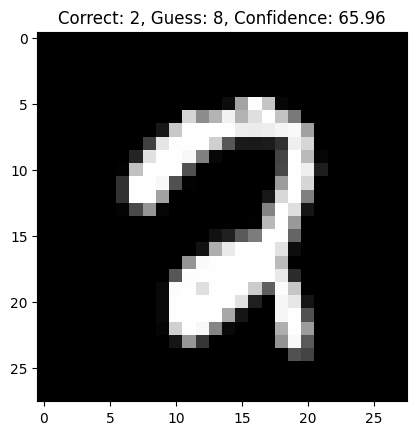

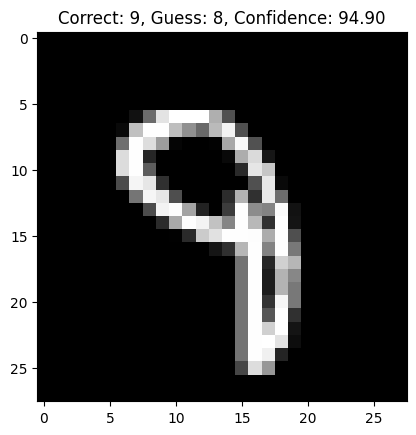

In [12]:
import numpy as np
import matplotlib.pyplot as plt

model2 = models.load_model("mnist_cnn.keras")

predictions = model2.predict(x_test)
predictions_values = np.argmax(predictions, axis=1)

incorrect_indexes = np.where(predictions_values != y_test)[0]

x_test = x_test.reshape(-1, 28, 28)

print(f"incorrect: {len(incorrect_indexes)}\ntotal: {len(y_test)}\naccuracy: {((len(y_test)-len(incorrect_indexes))/len(y_test))*100:.2f}")

for i in incorrect_indexes[:5]:
  plt.imshow(x_test[i], cmap="gray")
  plt.title(f"Correct: {y_test[i]}, Guess: {predictions_values[i]}, Confidence: {max(predictions[i])*100:.2f}")
  plt.show()
